# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Gensim for embeddings
from gensim.models import FastText, Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

# scikit-learn for utilities
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports loaded")

In [1]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Gensim for embeddings
from gensim.models import FastText, Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

# scikit-learn for utilities
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports loaded")

✓ Imports loaded


# Cell 2: Load Processed Data from Notebook 1

In [4]:


data_dir = Path("../data/processed")

print("Loading processed data...")

# Load dataframes
bbaw_clean = pd.read_parquet(data_dir / "bbaw_clean.parquet")
tla_clean = pd.read_parquet(data_dir / "tla_clean.parquet")

try:
    ramses_clean = pd.read_parquet(data_dir / "ramses_clean.parquet")
    print("✓ Ramses data loaded")
except FileNotFoundError:
    ramses_clean = None
    print("⚠ No Ramses data found")

try:
    lexicon_df = pd.read_parquet(data_dir / "lexicon.parquet")
    print("✓ Lexicon loaded")
except FileNotFoundError:
    lexicon_df = None
    print("⚠ No lexicon found")

# Load vocabularies
with open(data_dir / "egyptian_vocab.pkl", 'rb') as f:
    egyptian_vocab = pickle.load(f)

with open(data_dir / "german_vocab.pkl", 'rb') as f:
    german_vocab = pickle.load(f)

# Load corpora
with open(data_dir / "egyptian_corpus.pkl", 'rb') as f:
    egyptian_corpus = pickle.load(f)

with open(data_dir / "german_corpus.pkl", 'rb') as f:
    german_corpus = pickle.load(f)

# Load n-grams
try:
    with open(data_dir / "ngrams.pkl", 'rb') as f:
        ngrams = pickle.load(f)
    print("✓ N-grams loaded")
except FileNotFoundError:
    ngrams = None
    print("⚠ No n-grams found")

# Load metadata
with open(data_dir / "corpus_metadata.json", 'r') as f:
    corpus_metadata = json.load(f)

print("\n" + "="*60)
print("DATA LOADED")
print("="*60)
print(f"Egyptian corpus: {len(egyptian_corpus):,} sentences")
print(f"German corpus:   {len(german_corpus):,} sentences")
print(f"Egyptian vocab:  {len(egyptian_vocab):,} tokens")
print(f"German vocab:    {len(german_vocab):,} tokens")

Loading processed data...
✓ Ramses data loaded
✓ Lexicon loaded
✓ N-grams loaded

DATA LOADED
Egyptian corpus: 121,652 sentences
German corpus:   112,284 sentences
Egyptian vocab:  55,072 tokens
German vocab:    36,263 tokens


# Cell 3: Build Co-occurrence Matrix from N-grams

In [5]:


def build_cooccurrence_from_ngrams(ngrams, window_size=5):
    """
    Build co-occurrence matrix from n-gram statistics.
    This gives us more robust statistics than corpus alone.
    """
    cooccur = defaultdict(float)
    
    if ngrams is None:
        print("⚠ No n-grams available, will use corpus only")
        return None
    
    # Use bigrams as direct co-occurrence evidence
    for (word1, word2), count in ngrams['bigrams'].items():
        cooccur[(word1, word2)] += count
        cooccur[(word2, word1)] += count  # Symmetric
    
    # Use trigrams to infer longer-distance co-occurrence
    for (w1, w2, w3), count in ngrams['trigrams'].items():
        # All pairs within the trigram
        cooccur[(w1, w2)] += count * 0.8  # Weight by distance
        cooccur[(w2, w3)] += count * 0.8
        cooccur[(w1, w3)] += count * 0.5  # Further apart = lower weight
        
        # Symmetric
        cooccur[(w2, w1)] += count * 0.8
        cooccur[(w3, w2)] += count * 0.8
        cooccur[(w3, w1)] += count * 0.5
    
    print(f"Built co-occurrence matrix with {len(cooccur):,} word pairs")
    return dict(cooccur)

# Build co-occurrence matrix
if ngrams is not None:
    ngram_cooccur = build_cooccurrence_from_ngrams(ngrams, window_size=5)
    
    # Show some examples
    print("\nTop co-occurring pairs from n-grams:")
    top_pairs = sorted(ngram_cooccur.items(), key=lambda x: x[1], reverse=True)[:10]
    for (w1, w2), count in top_pairs:
        print(f"  {w1} ↔ {w2}: {count:.1f}")
else:
    ngram_cooccur = None

Built co-occurrence matrix with 38,065 word pairs

Top co-occurring pairs from n-grams:
  M17 ↔ M17: 12900.8
  Z1 ↔ Z1: 8855.8
  N35 ↔ X1: 6156.8
  X1 ↔ N35: 6156.8
  M17 ↔ Z7: 5450.2
  Z7 ↔ M17: 5450.2
  X1 ↔ Z7: 5088.5
  Z7 ↔ X1: 5088.5
  G1 ↔ G41: 4928.4
  G41 ↔ G1: 4928.4


# Cell 4: Augment Co-occurrence with Corpus Statistics

In [6]:


def count_corpus_cooccurrence(corpus, window_size=5):
    """
    Count co-occurrences from actual corpus.
    This complements n-gram statistics with context from BBAW/TLA.
    """
    cooccur = defaultdict(float)
    
    for sentence in tqdm(corpus, desc="Counting co-occurrences"):
        for i, word in enumerate(sentence):
            # Look at context window
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            
            for j in range(start, end):
                if i != j:
                    context_word = sentence[j]
                    distance = abs(i - j)
                    weight = 1.0 / distance  # Closer words = higher weight
                    
                    cooccur[(word, context_word)] += weight
    
    return dict(cooccur)

# Count from Egyptian corpus
print("Counting co-occurrences from Egyptian corpus...")
corpus_cooccur = count_corpus_cooccurrence(egyptian_corpus, window_size=5)

print(f"Corpus co-occurrence pairs: {len(corpus_cooccur):,}")

# Show examples
print("\nTop co-occurring pairs from corpus:")
top_pairs = sorted(corpus_cooccur.items(), key=lambda x: x[1], reverse=True)[:10]
for (w1, w2), count in top_pairs:
    print(f"  {w1} ↔ {w2}: {count:.1f}")

Counting co-occurrences from Egyptian corpus...


Counting co-occurrences:   0%|          | 0/121652 [00:00<?, ?it/s]

Corpus co-occurrence pairs: 1,592,104

Top co-occurring pairs from corpus:
  n ↔ =f: 8967.8
  =f ↔ n: 8967.8
  =k ↔ n: 8789.5
  n ↔ =k: 8789.5
  =f ↔ =f: 8067.0
  =f ↔ m: 7464.7
  m ↔ =f: 7464.7
  =k ↔ =k: 6359.5
  1 ↔ 1: 5881.2
  m ↔ =k: 5871.8


# Cell 5: Combine N-gram and Corpus Co-occurrence

In [7]:


def merge_cooccurrence(ngram_cooccur, corpus_cooccur, ngram_weight=2.0):
    """
    Merge n-gram statistics with corpus co-occurrence.
    N-grams get higher weight because they come from larger JSesh database.
    """
    merged = defaultdict(float)
    
    # Add corpus co-occurrence
    if corpus_cooccur:
        for pair, count in corpus_cooccur.items():
            merged[pair] += count
    
    # Add n-gram co-occurrence with higher weight
    if ngram_cooccur:
        for pair, count in ngram_cooccur.items():
            merged[pair] += count * ngram_weight
    
    return dict(merged)

# Merge co-occurrence matrices
print("Merging co-occurrence statistics...")
if ngram_cooccur is not None:
    merged_cooccur = merge_cooccurrence(ngram_cooccur, corpus_cooccur, ngram_weight=2.0)
    print(f"✓ Using n-gram + corpus co-occurrence (n-grams weighted 2x)")
else:
    merged_cooccur = corpus_cooccur
    print(f"✓ Using corpus co-occurrence only")

print(f"Total unique word pairs: {len(merged_cooccur):,}")

# Show top merged pairs
print("\nTop co-occurring pairs (merged):")
top_pairs = sorted(merged_cooccur.items(), key=lambda x: x[1], reverse=True)[:15]
for (w1, w2), count in top_pairs:
    print(f"  {w1} ↔ {w2}: {count:.1f}")

Merging co-occurrence statistics...
✓ Using n-gram + corpus co-occurrence (n-grams weighted 2x)
Total unique word pairs: 1,630,169

Top co-occurring pairs (merged):
  M17 ↔ M17: 25801.6
  Z1 ↔ Z1: 17711.6
  N35 ↔ X1: 12313.6
  X1 ↔ N35: 12313.6
  M17 ↔ Z7: 10900.4
  Z7 ↔ M17: 10900.4
  X1 ↔ Z7: 10177.0
  Z7 ↔ X1: 10177.0
  G1 ↔ G41: 9856.8
  G41 ↔ G1: 9856.8
  G1 ↔ M17: 9675.6
  M17 ↔ G1: 9675.6
  N35 ↔ N35: 9373.2
  M17 ↔ N35: 9188.8
  N35 ↔ M17: 9188.8


# Cell 6: Training Callback for Progress Monitoring

In [8]:


class TrainingCallback(CallbackAny2Vec):
    """Callback to monitor training progress"""
    def __init__(self):
        self.epoch = 0
        self.losses = []
    
    def on_epoch_begin(self, model):
        print(f"Epoch {self.epoch + 1} starting...", end=' ')
    
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        self.losses.append(loss)
        print(f"Loss: {loss:,.0f}")
        self.epoch += 1

print("✓ Training callback defined")

✓ Training callback defined


# Cell 7: Train Egyptian FastText Model

In [9]:


print("="*60)
print("TRAINING EGYPTIAN FASTTEXT")
print("="*60)

# FastText hyperparameters
fasttext_params = {
    'vector_size': 300,        # Standard embedding dimension
    'window': 5,               # Context window (Egyptian syntax relatively fixed)
    'min_count': 3,            # Include rare words (limited corpus)
    'sg': 1,                   # Skip-gram (better for rare words)
    'negative': 10,            # Negative sampling
    'epochs': 20,              # More epochs for small corpus
    'word_ngrams': 1,          # Use character n-grams (helps with morphology)
    'min_n': 3,                # Min character n-gram length
    'max_n': 6,                # Max character n-gram length
    'workers': 4,              # Parallel processing
    'seed': 42                 # Reproducibility
}

print(f"\nHyperparameters:")
for key, val in fasttext_params.items():
    print(f"  {key}: {val}")

print(f"\nTraining on {len(egyptian_corpus):,} sentences...")
print(f"Vocabulary size: {len(egyptian_vocab):,} tokens")

# Train model
callback = TrainingCallback()
egyptian_ft = FastText(
    sentences=egyptian_corpus,
    callbacks=[callback],
    **fasttext_params
)

print(f"\n✓ Egyptian FastText trained!")
print(f"  Final vocabulary size: {len(egyptian_ft.wv):,} words")
print(f"  Vector dimensionality: {egyptian_ft.wv.vector_size}")

TRAINING EGYPTIAN FASTTEXT

Hyperparameters:
  vector_size: 300
  window: 5
  min_count: 3
  sg: 1
  negative: 10
  epochs: 20
  word_ngrams: 1
  min_n: 3
  max_n: 6
  workers: 4
  seed: 42

Training on 121,652 sentences...
Vocabulary size: 55,072 tokens
Epoch 1 starting... Loss: 0
Epoch 2 starting... Loss: 0
Epoch 3 starting... Loss: 0
Epoch 4 starting... Loss: 0
Epoch 5 starting... Loss: 0
Epoch 6 starting... Loss: 0
Epoch 7 starting... Loss: 0
Epoch 8 starting... Loss: 0
Epoch 9 starting... Loss: 0
Epoch 10 starting... Loss: 0
Epoch 11 starting... Loss: 0
Epoch 12 starting... Loss: 0
Epoch 13 starting... Loss: 0
Epoch 14 starting... Loss: 0
Epoch 15 starting... Loss: 0
Epoch 16 starting... Loss: 0
Epoch 17 starting... Loss: 0
Epoch 18 starting... Loss: 0
Epoch 19 starting... Loss: 0
Epoch 20 starting... Loss: 0

✓ Egyptian FastText trained!
  Final vocabulary size: 17,041 words
  Vector dimensionality: 300


# Cell 8: Validate Egyptian Embeddings

In [10]:


def find_similar_words(model, word, topn=10):
    """Find most similar words"""
    try:
        similar = model.wv.most_similar(word, topn=topn)
        return similar
    except KeyError:
        return None

print("="*60)
print("EGYPTIAN FASTTEXT VALIDATION")
print("="*60)

# Test with common Egyptian words
test_words = [
    'nṯr',    # god
    'nswt',   # king
    'ḥm',     # majesty
    'jmn',    # Amun
    'rꜥ',     # Re
    'ḏd',     # say/speak
    'jrj',    # do/make
    'nfr',    # good/beautiful
    'tꜣ',     # land
    'pr',     # house
]

print("\nSemantic similarity tests:\n")
for word in test_words:
    if word in egyptian_ft.wv:
        similar = find_similar_words(egyptian_ft, word, topn=5)
        if similar:
            print(f"{word}:")
            for sim_word, score in similar:
                print(f"  {sim_word}: {score:.3f}")
            print()
    else:
        print(f"{word}: not in vocabulary\n")

# Test subword capability (important for morphology)
print("\nSubword capability test (OOV handling):")
oov_words = ['nṯr.w', 'nswt.w', 'jrj.n']  # Inflected forms
for word in oov_words:
    if word not in egyptian_ft.wv:
        # FastText can still generate embeddings for OOV words
        vec = egyptian_ft.wv[word]
        print(f"{word}: OOV but vector generated ✓ (dim={len(vec)})")

EGYPTIAN FASTTEXT VALIDATION

Semantic similarity tests:

nṯr:
  nṯrr: 0.636
  +nṯr: 0.635
  nṯr,t: 0.561
  〈nṯr〉: 0.537
  nṯr?: 0.531

nswt:
  nswt?: 0.822
  (n)swt: 0.718
  r-ḫ-nswt: 0.653
  nswt.ypl: 0.645
  wḏ-nswt: 0.631

ḥm:
  Ḏdj: 0.423
  ḥmꞽ: 0.419
  ḏdꞽ: 0.418
  ḥmj: 0.409
  Wbꜣ-jnr: 0.402

jmn:
  jmnt: 0.694
  jmn.ṱ: 0.682
  wn-jmn: 0.664
  jmn-rꜥ: 0.664
  j.jr.n-jmn: 0.664

rꜥ:
  rꜥ-wsr: 0.621
  sḫm-rꜥ-šd-tꜣ.wy: 0.620
  rꜥ-ms: 0.611
  sḳnn-rꜥ: 0.605
  tꜣ.wy: 0.598

ḏd:
  r:ḏd: 0.589
  〈r〉-ḏd: 0.523
  ḏd.〈j〉n: 0.518
  jḫ-ḏd: 0.499
  ḏd.t〈j〉n: 0.496

jrj:
  jrj=j: 0.794
  jrjt: 0.768
  jrj.y: 0.691
  j.jrj: 0.649
  jḫ-jrj: 0.640

nfr:
  s:nfr: 0.675
  nfrj: 0.639
  +nfr: 0.595
  〈nfr〉: 0.591
  nfr?: 0.589

tꜣ:
  tꜣtꜣ: 0.600
  tꜣ_: 0.487
  r-ḏr: 0.471
  Mw~š~nṯ: 0.456
  tꜣy?: 0.444

pr:
  prꞽ: 0.496
  prḫ: 0.490
  prt: 0.446
  pry: 0.439
  mnṯw-nḫt: 0.436


Subword capability test (OOV handling):


# Cell 9: Train German FastText Model (for comparison)

In [11]:


print("="*60)
print("TRAINING GERMAN FASTTEXT")
print("="*60)

# Similar parameters to Egyptian
german_fasttext_params = {
    'vector_size': 300,
    'window': 5,
    'min_count': 3,
    'sg': 1,
    'negative': 10,
    'epochs': 20,
    'word_ngrams': 1,
    'min_n': 3,
    'max_n': 6,
    'workers': 4,
    'seed': 42
}

print(f"\nTraining on {len(german_corpus):,} sentences...")
print(f"Vocabulary size: {len(german_vocab):,} tokens")

callback = TrainingCallback()
german_ft = FastText(
    sentences=german_corpus,
    callbacks=[callback],
    **german_fasttext_params
)

print(f"\n✓ German FastText trained!")
print(f"  Final vocabulary size: {len(german_ft.wv):,} words")
print(f"  Vector dimensionality: {german_ft.wv.vector_size}")

TRAINING GERMAN FASTTEXT

Training on 112,284 sentences...
Vocabulary size: 36,263 tokens
Epoch 1 starting... Loss: 0
Epoch 2 starting... Loss: 0
Epoch 3 starting... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss: 0
Epoch 4 starting... Loss: 0
Epoch 5 starting... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss: 0
Epoch 6 starting... Loss: 0
Epoch 7 starting... Loss: 0
Epoch 8 starting... Loss: 0
Epoch 9 starting... Loss: 0
Epoch 10 starting... Loss: 0
Epoch 11 starting... 

...

Loss: 0
Epoch 13 starting... Loss: 0
Epoch 14 starting... Loss: 0
Epoch 15 starting... Loss: 0
Epoch 16 starting... Loss: 0
Epoch 17 starting... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss: 0
Epoch 18 starting... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss: 0
Epoch 19 starting... Loss: 0
Epoch 20 starting... Loss: 0

✓ German FastText trained!
  Final vocabulary size: 16,252 words
  Vector dimensionality: 300


# Cell 10: Validate German Embeddings

In [12]:


print("="*60)
print("GERMAN FASTTEXT VALIDATION")
print("="*60)

# Test with common German words from translations
test_words_de = [
    'gott',      # god
    'könig',     # king
    'pharao',    # pharaoh
    'tempel',    # temple
    'sagen',     # say
    'machen',    # do/make
    'gut',       # good
    'land',      # land
    'haus',      # house
]

print("\nSemantic similarity tests:\n")
for word in test_words_de:
    if word in german_ft.wv:
        similar = find_similar_words(german_ft, word, topn=5)
        if similar:
            print(f"{word}:")
            for sim_word, score in similar:
                print(f"  {sim_word}: {score:.3f}")
            print()
    else:
        print(f"{word}: not in vocabulary\n")

GERMAN FASTTEXT VALIDATION

Semantic similarity tests:

gott:
  got: 0.687
  gotte: 0.536
  mondgott: 0.530
  sonnengott: 0.484
  stadtgott: 0.464

könig:
  köni: 0.684
  königin: 0.659
  könige: 0.642
  königen: 0.584
  königtum: 0.571

pharao:
  pharaohs: 0.854
  phar: 0.854
  pharaos: 0.845
  phrarao: 0.758
  pha: 0.711

tempel:
  ptahtempel: 0.803
  tempeln: 0.800
  tempelbezirk: 0.755
  tempelbezirks: 0.735
  tempels: 0.733

sagen:
  sagend: 0.652
  sage: 0.613
  aussagen: 0.611
  sag: 0.571
  fragen: 0.551

machen:
  ausmachen: 0.847
  freimachen: 0.787
  aufmachen: 0.784
  wegmachen: 0.779
  festmachen: 0.729

gut:
  guts: 0.581
  gutes: 0.497
  gute: 0.489
  gua: 0.482
  guter: 0.464

land:
  lands: 0.645
  seeland: 0.614
  lande: 0.612
  landed: 0.582
  ausland: 0.576

haus:
  hause: 0.669
  turmhaus: 0.623
  bierhaus: 0.512
  frauenhaus: 0.511
  hau: 0.497



# Cell 11: Alternative - Load Pre-trained German FastText

In [13]:


# For better German embeddings, we can use pre-trained models
# Download from: https://fasttext.cc/docs/en/crawl-vectors.html

print("="*60)
print("LOADING PRE-TRAINED GERMAN FASTTEXT (OPTIONAL)")
print("="*60)

pretrained_path = "cc.de.300.bin"  # Update path if you have it

try:
    from gensim.models import FastText
    print(f"Loading pre-trained German FastText from {pretrained_path}...")
    print("(This may take a few minutes...)")
    
    german_ft_pretrained = FastText.load_fasttext_format(pretrained_path)
    
    print(f"✓ Pre-trained German FastText loaded!")
    print(f"  Vocabulary size: {len(german_ft_pretrained.wv):,} words")
    print(f"  Vector dimensionality: {german_ft_pretrained.wv.vector_size}")
    
    # Use pre-trained model going forward
    german_ft_final = german_ft_pretrained
    print("\n✓ Using pre-trained German embeddings for alignment")
    
except FileNotFoundError:
    print(f"⚠ Pre-trained model not found at {pretrained_path}")
    print("Using our trained German FastText model instead")
    print("\nTo use pre-trained embeddings:")
    print("1. Download from: https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.de.300.bin.gz")
    print("2. Extract and place in working directory")
    
    german_ft_final = german_ft
    
except Exception as e:
    print(f"⚠ Error loading pre-trained model: {e}")
    print("Using our trained German FastText model instead")
    german_ft_final = german_ft

LOADING PRE-TRAINED GERMAN FASTTEXT (OPTIONAL)
Loading pre-trained German FastText from cc.de.300.bin...
(This may take a few minutes...)
⚠ Pre-trained model not found at cc.de.300.bin
Using our trained German FastText model instead

To use pre-trained embeddings:
1. Download from: https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.de.300.bin.gz
2. Extract and place in working directory


# Cell 12: Save Trained Models

In [14]:


output_dir = Path("models")
output_dir.mkdir(exist_ok=True)

print("Saving models...")

# Save Egyptian FastText
egyptian_ft.save(str(output_dir / "egyptian_fasttext.model"))
print(f"✓ Egyptian FastText saved to {output_dir}/egyptian_fasttext.model")

# Save German FastText (our trained version)
german_ft.save(str(output_dir / "german_fasttext.model"))
print(f"✓ German FastText saved to {output_dir}/german_fasttext.model")

# Save model metadata
model_metadata = {
    'egyptian': {
        'vocab_size': len(egyptian_ft.wv),
        'vector_size': egyptian_ft.wv.vector_size,
        'corpus_size': len(egyptian_corpus),
        'parameters': fasttext_params
    },
    'german': {
        'vocab_size': len(german_ft.wv),
        'vector_size': german_ft.wv.vector_size,
        'corpus_size': len(german_corpus),
        'parameters': german_fasttext_params
    }
}

with open(output_dir / "model_metadata.json", 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"✓ Model metadata saved")

Saving models...
✓ Egyptian FastText saved to models/egyptian_fasttext.model
✓ German FastText saved to models/german_fasttext.model
✓ Model metadata saved


# Cell 13: Visualize Embedding Spaces (Optional)

Visualizing Egyptian embeddings...


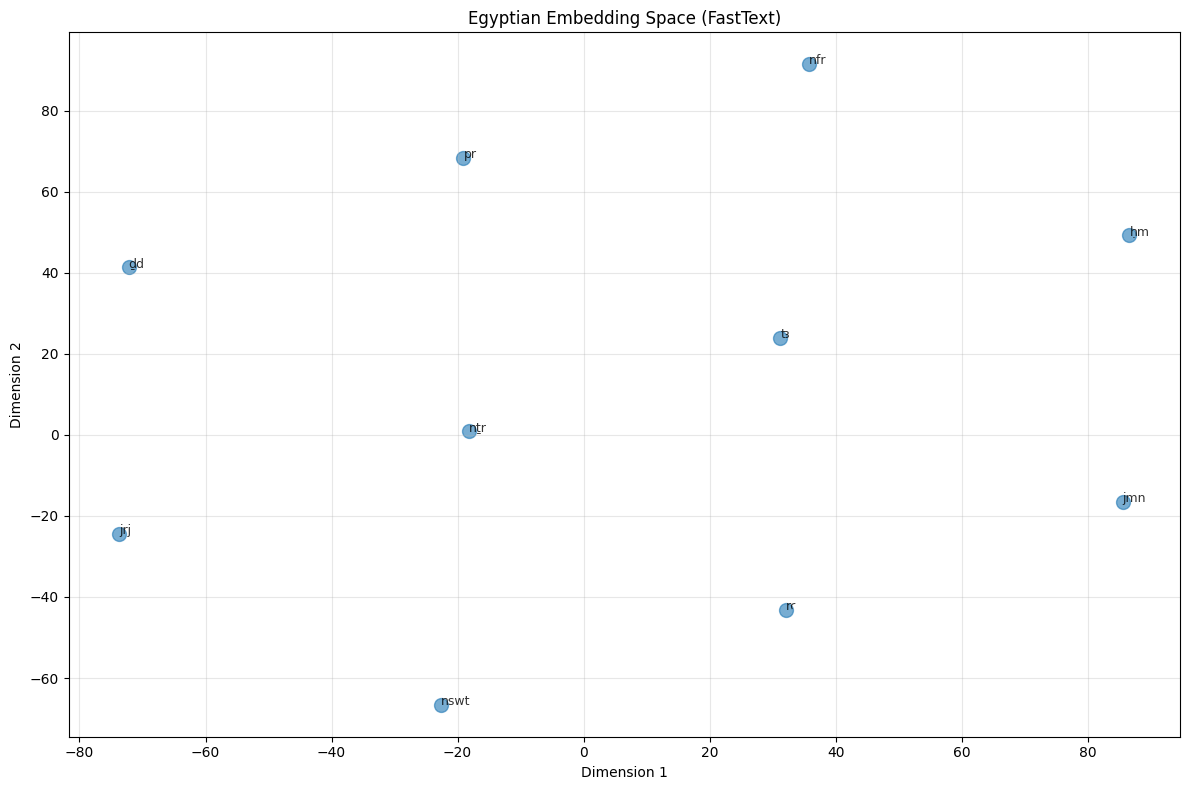


Visualizing German embeddings...


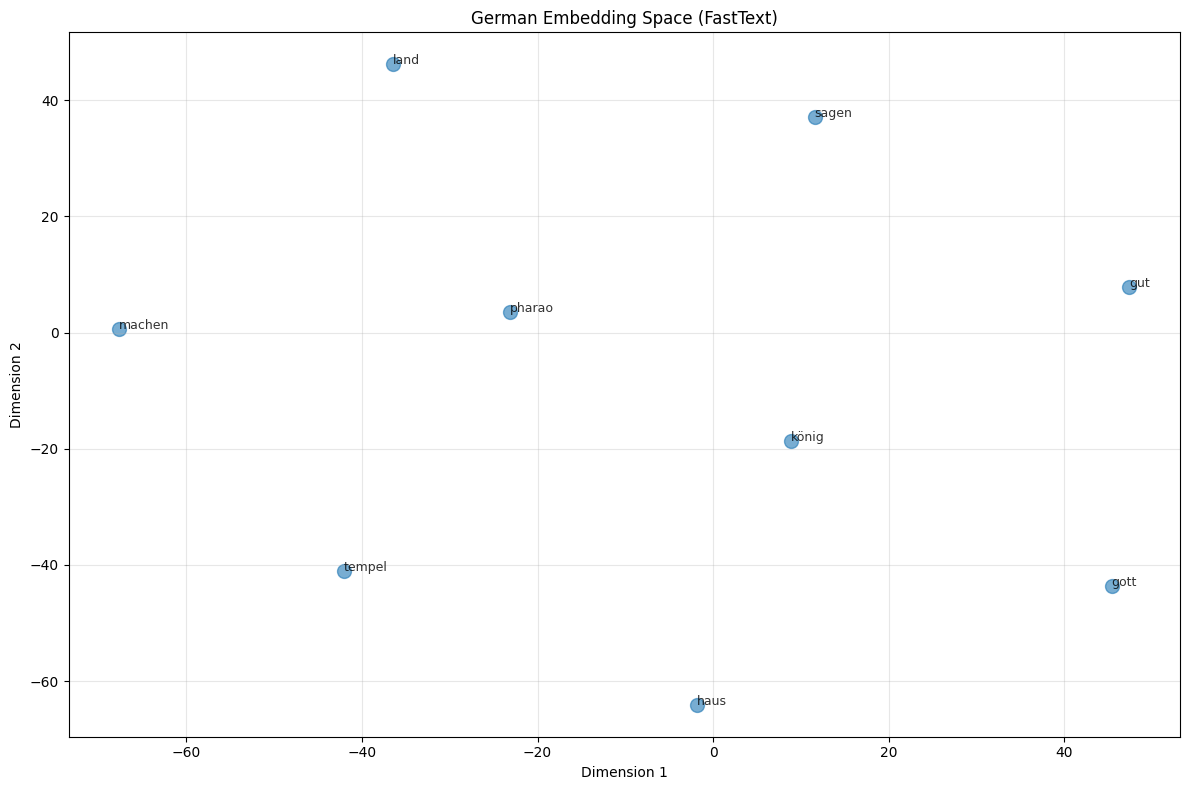

In [15]:


def visualize_embeddings(model, words, title, method='tsne'):
    """
    Visualize embeddings in 2D using t-SNE or PCA
    """
    # Get vectors for words that exist in vocabulary
    vectors = []
    labels = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
            labels.append(word)
    
    if len(vectors) < 2:
        print(f"Not enough words in vocabulary for visualization")
        return
    
    vectors = np.array(vectors)
    
    # Reduce to 2D
    if method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(vectors)-1))
    else:
        reducer = PCA(n_components=2, random_state=42)
    
    coords = reducer.fit_transform(vectors)
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=100)
    
    for i, label in enumerate(labels):
        plt.annotate(label, (coords[i, 0], coords[i, 1]), 
                    fontsize=9, alpha=0.8)
    
    plt.title(title)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize Egyptian embeddings
print("Visualizing Egyptian embeddings...")
egyptian_words = [w for w in test_words if w in egyptian_ft.wv][:20]
if len(egyptian_words) > 2:
    visualize_embeddings(egyptian_ft, egyptian_words, 
                        'Egyptian Embedding Space (FastText)', method='tsne')

# Visualize German embeddings
print("\nVisualizing German embeddings...")
german_words = [w for w in test_words_de if w in german_ft_final.wv][:20]
if len(german_words) > 2:
    visualize_embeddings(german_ft_final, german_words,
                        'German Embedding Space (FastText)', method='tsne')

# Cell 14: Summary Statistics

In [16]:
# Cell 14: Summary Statistics

print("="*60)
print("EMBEDDING TRAINING COMPLETE - SUMMARY")
print("="*60)

print("\n📊 Egyptian FastText:")
print(f"  Vocabulary: {len(egyptian_ft.wv):,} words")
print(f"  Dimensions: {egyptian_ft.wv.vector_size}")
print(f"  Training corpus: {len(egyptian_corpus):,} sentences")
print(f"  Includes: BBAW + TLA" + (" + Ramses" if ramses_clean is not None else ""))

print("\n📊 German FastText:")
print(f"  Vocabulary: {len(german_ft_final.wv):,} words")
print(f"  Dimensions: {german_ft_final.wv.vector_size}")
if german_ft_final == german_ft:
    print(f"  Training corpus: {len(german_corpus):,} sentences")
    print(f"  Type: Trained on BBAW + TLA")
else:
    print(f"  Type: Pre-trained (Common Crawl)")

print("\n💾 Models saved to:", output_dir.absolute())

print("\n✓ Ready for Procrustes alignment (Notebook 3)!")

EMBEDDING TRAINING COMPLETE - SUMMARY

📊 Egyptian FastText:
  Vocabulary: 17,041 words
  Dimensions: 300
  Training corpus: 121,652 sentences
  Includes: BBAW + TLA + Ramses

📊 German FastText:
  Vocabulary: 16,252 words
  Dimensions: 300
  Training corpus: 112,284 sentences
  Type: Trained on BBAW + TLA

💾 Models saved to: /Users/crashy/Development/heiroglyphy/heiro_v12/notebooks/models

✓ Ready for Procrustes alignment (Notebook 3)!
